In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [37]:
import pandas as pd
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from PIL import Image
import glob
import shutil

In [45]:
#data exploration
csv_path=os.listdir("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA")
count=0
totalcount=0
for paths in csv_path:
    totalcount+=1
    if paths.endswith('.jpg'):
        act_path=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths)
        #dat=pd.read_csv(act_path)
        # pd.set_option('display.max_rows', None)
        # pd.set_option('display.max_columns', None)
        # print(dat)
        imgpth=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths.replace(".jpg",".csv"))
        if not os.path.isfile(imgpth):
            count+=1
            print(paths)
print("img with no csv=",count)
            
        


1665-M-014Y1(1).jpg
img with no csv= 1


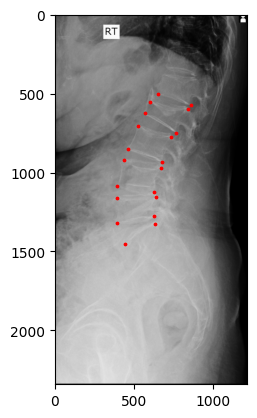

   685.9785   381.5689  902.6589   413.2783  0
0  650.0413   501.0074  863.5508   570.7679  0
1  603.5342   554.9133  844.5252   595.0784  0
2  568.6540   624.6738  767.3658   746.2263  0
3  527.4319   703.9471  735.6565   772.6507  0
4  461.8993   851.9240  676.4658   933.3113  0
5  435.4748   921.6846  671.1808   973.4764  0
6  395.3097  1083.4020  625.7308  1122.5100  0
7  391.0818  1160.5620  642.6425  1156.3340  0
8  395.3097  1322.2790  629.9587  1274.7150  0
9  446.0446  1451.2300  633.1296  1323.3360  0


In [59]:
#data exploration on images
imagedir='/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA'
csvdir=imagedir
count =0
for fname in os.listdir(imagedir):
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        csvname=name+'.csv'
        csvpth=os.path.join(csvdir,csvname)
        info=pd.read_csv(csvpth)

        fig,ax=plt.subplots()
        ax.imshow(img)
        ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
        ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        print(info)
        count+=1
        if count>0:
            break

In [41]:
#data cleaning
csv_path=os.listdir("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA")
dst="/kaggle/working/clean_data/"
csvdst = "/kaggle/working/clean_data/csv"
imgdst="/kaggle/working/clean_data/img"
os.makedirs(dst, exist_ok=True)
os.makedirs(csvdst, exist_ok=True)
os.makedirs(imgdst, exist_ok=True)
count=0
totalcount=0
for paths in csv_path:
    
    if paths.endswith('.csv'):
        totalcount+=1
        act_path=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths)
        #dat=pd.read_csv(act_path)
        # pd.set_option('display.max_rows', None)
        # pd.set_option('display.max_columns', None)
        # print(dat)
        imgpth=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths.replace(".csv",".jpg"))
        if os.path.isfile(imgpth):
            shutil.copy(act_path, csvdst)
            shutil.copy(imgpth, imgdst)
        else:
            print(paths,'skipped')
print('done')
            
        


1674-F-050Y1(1).csv skipped
1669-M-048Y1(1).csv skipped
1667-F-065Y1(1).csv skipped
done


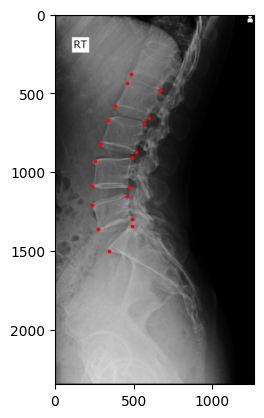

In [62]:
#data exploration on images after cleaning
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/working/clean_data/csv"
count =0
for fname in os.listdir(imagedir):
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        csvname=name+'.csv'
        csvpth=os.path.join(csvdir,csvname)
        info=pd.read_csv(csvpth)

        fig,ax=plt.subplots()
        ax.imshow(img)
        ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
        ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break


/tmp/ipykernel_58/1026275508.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(info.loc[name][5],info.loc[name][6],c='red',s=3)


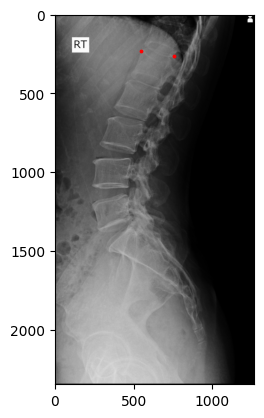

In [80]:
#data on excel
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"

count =0
info=pd.read_excel(csvdir,sheet_name='Pos_LA',index_col='filename')
for fname in os.listdir(imagedir):
    
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        fig,ax=plt.subplots()
        ax.imshow(img)
        if name in info.index:
            row_data = info.loc[name]
        #use this:
        ax.scatter(row_data.iloc[3],row_data.iloc[4],c='red',s=3)
        #avoid this:
        ax.scatter(info.loc[name][5],info.loc[name][6],c='red',s=3)
        
        #ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break

Anterolisthesis


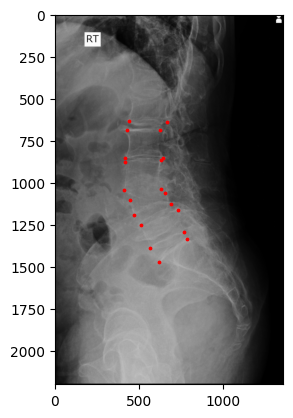

Retrolisthesis


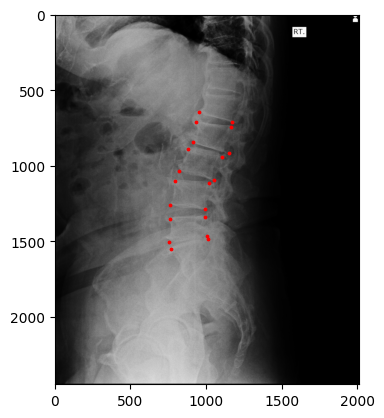

note: no left or right Laterolisthesis as dataset is dealing with only sagittal view


In [85]:
#data on excel according to diagnosis
imagedir='/kaggle/working/clean_data/img'
xldir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"
csvdir="/kaggle/working/clean_data/csv"
count1,count2,count3,count4=0,0,0,0
diaginfo=pd.read_excel(xldir,sheet_name='diagnosis',index_col='filename')

for fname in os.listdir(imagedir):
    
    
    if fname.endswith('.jpg'):
        name=os.path.splitext(fname)[0]
        if name in diaginfo.index:
            current_diagnosis = diaginfo.loc[name, 'diagnosis_number']
            
                
            if current_diagnosis == 3 and count3 == 0:
                print("Anterolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count3 += 1
                
            elif current_diagnosis == 4 and count4 == 0:
                print("Retrolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count4 += 1
            
            
            if count3 > 0 and count4 > 0:
                break
print("note: no left or right Laterolisthesis as dataset is dealing with only sagittal view")